# 3.6 — Modèles génératifs : trois objectifs, trois échecs — VAE, GAN et diffusion sur une distribution multimodale bornée

**Navigation** : [<< 3.5-Grokking et double descente](3.5-Phenomenes-de-Generalisation.ipynb) · [Feuille de route de la série](README.md) · VAE applicatif : [QC-Py-24 (autoencodeurs d'anomalies)](../../../QuantConnect/Python/QC-Py-24-Autoencoders-Anomaly.ipynb)

Nos notebooks consomment des modèles génératifs partout — les autoencodeurs d'anomalies de [QC-Py-24](../../../QuantConnect/Python/QC-Py-24-Autoencoders-Anomaly.ipynb), les diffuseurs des notebooks GenAI/Image — mais toujours comme des boîtes noires. Ce notebook ouvre trois de ces boîtes **côte à côte** : un **VAE**, un **GAN** et un petit **modèle de diffusion (DDPM)**, chacun écrit en NumPy pur sur la machinerie du [3.1](3.1-Retropropagation.ipynb) (backward à la main) et l'Adam du [3.2](3.2-Optimisateurs.ipynb). Pas une ligne de PyTorch.

La thèse : **les trois familles n'optimisent pas la même chose**, donc elles n'échouent pas de la même façon. Le VAE maximise une borne de la log-vraisemblance (reconstruction + régularisation vers le prior) — il couvre, mais il **moyenne**. Le GAN optimise un duel minimax — ses échantillons sont nets, mais rien dans son objectif ne force la **couverture des modes**. La diffusion apprend à débruiter pas à pas — elle raffine itérativement, au prix d'un **échantillonnage séquentiel**. Pour rendre ces échecs *mesurables*, les trois modèles s'entraînent sur la même distribution bornée — huit modes sur un cercle — avec le même budget (pas, batch, largeur), contre une baseline **GMM ajustée par EM** qui fixe la barre : quand le biais inductif colle au problème, l'apprentissage profond est superflu.

Ce notebook ne prétend pas reproduire FLUX ou Stable Diffusion — il isole les **mécanismes** que ces moteurs SOTA consomment (discussion finale).

***

Jeu d'entrainement : 8192 points, 8 modes separes, rayon 1.6, std intra-mode 0.06
Domaine observe : x1 in [-1.80, 1.78] ; x2 in [-1.81, 1.84]


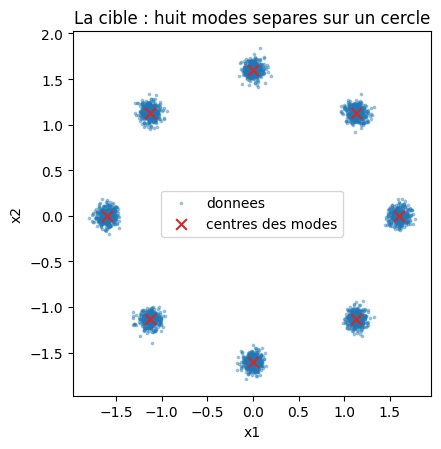

In [1]:
# Imports, hyperparametres canoniques, donnees : huit modes sur un cercle (domaine borne)
import time
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

N_MODES = 8      # nombre de modes de la cible
RADIUS  = 1.6    # rayon du cercle portant les modes
STD     = 0.06   # ecart-type intra-mode (modes bien separes)
N_TRAIN = 8192   # jeu d'entrainement commun a tous les modeles
SEED    = 42     # graine de la demonstration ; le protocole multi-graines vient en fin de notebook
SEEDS   = [0, 1, 7, 42]

def centres_modes():
    ang = 2 * np.pi * np.arange(N_MODES) / N_MODES
    return np.column_stack([RADIUS * np.cos(ang), RADIUS * np.sin(ang)])

CENTERS = centres_modes()

def make_data(n, rng):
    ks = rng.integers(0, N_MODES, n)
    return CENTERS[ks] + rng.normal(0, STD, (n, 2))

X = make_data(N_TRAIN, np.random.default_rng(SEED))
print(f"Jeu d'entrainement : {N_TRAIN} points, {N_MODES} modes separes, rayon {RADIUS}, std intra-mode {STD}")
print(f"Domaine observe : x1 in [{X[:,0].min():.2f}, {X[:,0].max():.2f}] ; x2 in [{X[:,1].min():.2f}, {X[:,1].max():.2f}]")

fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.scatter(X[:3000, 0], X[:3000, 1], s=3, alpha=0.35, color="tab:blue", label="donnees")
ax.scatter(CENTERS[:, 0], CENTERS[:, 1], s=60, marker="x", color="tab:red", label="centres des modes")
ax.set_title("La cible : huit modes separes sur un cercle")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.legend(); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

In [2]:
# Metriques communes + baseline GMM ajustee par EM
# Trois mesures, appliquees a TOUT modele (GMM, VAE, GAN, diffusion), 4096 echantillons :
#  - couverture  : modes recevant >= 2 % des echantillons (le collapse se voit ici)
#  - equilibre   : entropie de l'occupation normalisee par log(8)  (1.0 = masse parfaitement repartie)
#  - dispersion  : distance mediane au mode le plus proche, RELATIVE a celle des vraies donnees (1.0 = net)
def occupation(echantillons):
    d2 = ((echantillons[:, None, :] - CENTERS[None, :, :]) ** 2).sum(-1)
    return np.bincount(d2.argmin(1), minlength=N_MODES) / len(echantillons)

def couverture(echantillons, part_min=0.02):
    parts = occupation(echantillons)
    return int((parts >= part_min).sum())

def equilibre(echantillons):
    parts = occupation(echantillons)
    return float(-(parts * np.log(parts + 1e-12)).sum() / np.log(N_MODES))

def dispersion_relative(echantillons):
    d_vrai = np.sqrt(((X[:, None, :] - CENTERS[None, :, :]) ** 2).sum(-1)).min(1)
    d_ech  = np.sqrt(((echantillons[:, None, :] - CENTERS[None, :, :]) ** 2).sum(-1)).min(1)
    return float(np.median(d_ech) / np.median(d_vrai))

# --- Baseline : GMM diagonal ajuste par EM (aucun gradient, aucun reseau) ---
def gmm_em(X, K, rng, iters=100):
    n = len(X)
    mu  = X[rng.choice(n, K, replace=False)].copy()
    var = np.full((K, 2), X.var(0))
    pi  = np.full(K, 1 / K)
    for _ in range(iters):
        logcomp = np.log(pi)[None] - 0.5 * np.sum(np.log(2 * np.pi * var[None])
                                                  + (X[:, None, :] - mu[None]) ** 2 / var[None], -1)
        m = logcomp.max(1, keepdims=True)
        ll = float((m[:, 0] + np.log(np.exp(logcomp - m).sum(1))).sum())   # log-vraisemblance (log-sum-exp)
        r = np.exp(logcomp - m); r /= r.sum(1, keepdims=True)
        Nk = r.sum(0) + 1e-9
        mu  = (r.T @ X) / Nk[:, None]
        var = (r[:, :, None] * (X[:, None, :] - mu[None]) ** 2).sum(0) / Nk[:, None] + 1e-6
        pi  = Nk / n
    return mu, var, pi, ll

def gmm_echantillon(mu, var, pi, n, rng):
    ks = rng.choice(len(pi), n, p=pi / pi.sum())
    return mu[ks] + rng.normal(0, 1, (n, 2)) * np.sqrt(var[ks])

def gmm_em_multistart(X, K, n_restarts=3):
    """L'EM depend de son initialisation : une seule relance tombe parfois dans un
    optimum local (un composant chevauche son voisin). Pratique standard : quelques
    relances, on garde la meilleure log-vraisemblance."""
    best = None
    for i in range(n_restarts):
        res = gmm_em(X, K, np.random.default_rng(i))
        if best is None or res[3] > best[3]:
            best = res
    return best

t0 = time.time()
GMM_MU, GMM_VAR, GMM_PI, LL_GMM = gmm_em_multistart(X, N_MODES)
T_FIT_GMM = time.time() - t0
S_GMM = gmm_echantillon(GMM_MU, GMM_VAR, GMM_PI, 4096, np.random.default_rng(100))
print(f"GMM (EM x3, {T_FIT_GMM:.2f} s de fit, 0 gradient) : couverture {couverture(S_GMM)}/8 | equilibre {equilibre(S_GMM):.3f} | dispersion {dispersion_relative(S_GMM):.2f}")
ecart_centres = np.sqrt(((GMM_MU[:, None, :] - CENTERS[None, :, :]) ** 2).sum(-1)).min(1)
print(f"Centres retrouves par EM (apparies au plus proche vrai centre) : ecart max {ecart_centres.max():.4f}")

GMM (EM x3, 2.22 s de fit, 0 gradient) : couverture 8/8 | equilibre 0.999 | dispersion 0.99
Centres retrouves par EM (apparies au plus proche vrai centre) : ecart max 0.0036


**Lecture — la barre est fixée.** Le GMM couvre 8/8 modes, équilibre quasi parfait, dispersion ~1,0 (aussi net que les vraies données). Ce n'est pas de la triche : son biais inductif — huit ellipses gaussiennes — colle *exactement* à la cible choisie, et l'EM retrouve les centres au millième près. Un détail honnête : l'EM dépend de son **initialisation** — une seule relance tombe parfois dans un optimum local où un composant chevauche son voisin (essayez `n_restarts=1` : un centre reste décalé) — d'où les trois relances, on garde la meilleure log-vraisemblance. C'est le témoin qui rend les échecs des modèles profonds **mesurables** : si un réseau entraîné 6 000 pas fait moins bien qu'un EM de deux secondes, l'échec est dans l'*objectif*, pas dans la capacité.

Pourquoi alors des réseaux ? Parce que la vie réelle — images, audio, texte — n'est pas un mélange de huit gaussiennes : le GMM y explose (covariances en O(d²), modes mal définis). Les trois familles qui suivent échangent le biais inductif gratuit contre de la flexibilité — et chacune paie un prix différent, visible dans les mêmes trois métriques.

In [3]:
# La machinerie commune : MLP NumPy (backward a la main, style 3.1) + Adam (style 3.2)
class MLP:
    """MLP a activations tangentes, dernier couche lineaire par defaut.
    backward(dA) renvoie dX (gradient par rapport a l'entree) ET la liste des gradients parametres."""
    def __init__(self, dims, rng, out_linear=True):
        self.W = [rng.normal(0, 0.5 ** 0.5 / np.sqrt(dims[i]), (dims[i], dims[i + 1])) for i in range(len(dims) - 1)]
        self.b = [np.zeros(d) for d in dims[1:]]
        self.out_linear = out_linear
    def params(self):
        return self.W + self.b
    def n_params(self):
        return int(sum(p.size for p in self.params()))
    def forward(self, X):
        self.cache = [X]
        A = X
        L = len(self.W)
        for i in range(L):
            Z = A @ self.W[i] + self.b[i]
            H = Z if (i == L - 1 and self.out_linear) else np.tanh(Z)
            self.cache.append((A, H))
            A = H
        return A
    def backward(self, dA):
        gW = [None] * len(self.W); gb = [None] * len(self.b)
        L = len(self.W)
        for i in range(L - 1, -1, -1):
            A, H = self.cache[i + 1]
            dZ = dA if (i == L - 1 and self.out_linear) else dA * (1 - H ** 2)
            gW[i] = A.T @ dZ
            gb[i] = dZ.sum(0)
            dA = dZ @ self.W[i].T
        return dA, gW + gb

class Adam:
    def __init__(self, params, lr=1e-3):
        self.p = params
        self.m = [np.zeros_like(p) for p in params]; self.v = [np.zeros_like(p) for p in params]
        self.t = 0; self.lr = lr
    def step(self, grads):
        self.t += 1
        for i, (p, g) in enumerate(zip(self.p, grads)):
            self.m[i] = 0.9 * self.m[i] + 0.1 * g
            self.v[i] = 0.999 * self.v[i] + 0.001 * g * g
            mh = self.m[i] / (1 - 0.9 ** self.t); vh = self.v[i] / (1 - 0.999 ** self.t)
            p -= self.lr * mh / (np.sqrt(vh) + 1e-8)

H     = 64     # largeur commune des couches cachees
BATCH = 256    # taille de batch commune
STEPS = 6000   # budget de pas de gradient commun aux trois familles
N_ECH = 4096   # nombre d'echantillons pour chaque evaluation
print(f"Budget commun aux trois familles : {STEPS} pas de gradient, batch {BATCH}, couches cachees de largeur {H}")

Budget commun aux trois familles : 6000 pas de gradient, batch 256, couches cachees de largeur 64


In [4]:
# Garde (la discipline du 3.1) : gradient numerique vs analytique sur les deux chaines les plus risquees
# Chaine 1 : l'ELBO complet du VAE — reconstruction MOINS le chemin de reparametrisation z = mu + sigma*eps
B_G = 16
Xg = make_data(B_G, np.random.default_rng(0))
EPS_G = np.random.default_rng(1).normal(0, 1, (B_G, 2))
enc_g = MLP([2, 4, 4, 4], np.random.default_rng(0))
dec_g = MLP([2, 4, 4, 2], np.random.default_rng(2))

def elbo_et_grads():
    h = enc_g.forward(Xg); mu, lv = h[:, :2], h[:, 2:]
    z = mu + np.exp(0.5 * lv) * EPS_G
    xr = dec_g.forward(z)
    L = ((xr - Xg) ** 2).sum(1).mean() + 0.5 * (np.exp(lv) + mu ** 2 - 1 - lv).sum(1).mean()
    dz, gd = dec_g.backward(2 * (xr - Xg) / B_G)
    dmu = dz + mu / B_G
    dlv = dz * np.exp(0.5 * lv) * EPS_G * 0.5 + 0.5 * (np.exp(lv) - 1) / B_G
    _, ge = enc_g.backward(np.concatenate([dmu, dlv], 1))
    return L, ge + gd

def ecart_max_garde(modeles, loss_et_grads):
    """Pour chaque couche de chaque modele, sonde la plus grande composante analytique par difference finie."""
    _, g = loss_et_grads()
    worst = 0.0
    k = 0
    for net in modeles:
        for couche in net.params():
            gi = g[k]; k += 1
            idx = np.unravel_index(np.argmax(np.abs(gi)), couche.shape)
            orig, eps = couche[idx], 1e-6
            couche[idx] = orig + eps; Lp, _ = loss_et_grads()
            couche[idx] = orig - eps; Lm, _ = loss_et_grads()
            couche[idx] = orig
            num = (Lp - Lm) / (2 * eps)
            worst = max(worst, abs(num - gi[idx]) / max(abs(num), 1e-10))
    return worst

print(f"Garde VAE (ELBO + reparametrisation) : ecart relatif max = {ecart_max_garde([enc_g, dec_g], elbo_et_grads):.2e}")

# Chaine 2 : la MSE de prediction de bruit du DDPM (entree x_t conditionnee en t)
T = 100                      # nombre de pas de diffusion
BETAS = np.linspace(1e-4, 0.09, T)   # schedule lineaire ; cf. lecture de la section diffusion
ALPHAS_CUM = np.cumprod(1 - BETAS)

def t_feat(t):
    """Encodage du temps discre'tise en 7 features : t normalise + sin/cos a 3 frequences."""
    x = t[:, None]
    return np.concatenate([x, np.sin(2*np.pi*x), np.cos(2*np.pi*x),
                           np.sin(8*np.pi*x), np.cos(8*np.pi*x),
                           np.sin(24*np.pi*x), np.cos(24*np.pi*x)], 1)

net_g = MLP([2 + 7, 4, 4, 2], np.random.default_rng(5))
Xg2 = Xg[:8]; EPS_G2 = np.random.default_rng(6).normal(0, 1, (8, 2))
INP_G = np.concatenate([Xg2, t_feat(np.arange(8) / T)], 1)

def mse_bruit_et_grads():
    eh = net_g.forward(INP_G)
    L = ((eh - EPS_G2) ** 2).sum(1).mean()
    _, g = net_g.backward(2 * (eh - EPS_G2) / 8)
    return L, g

print(f"Garde diffusion (eps-net, x_t conditionne en t) : ecart relatif max = {ecart_max_garde([net_g], mse_bruit_et_grads):.2e}")

Garde VAE (ELBO + reparametrisation) : ecart relatif max = 1.39e-08
Garde diffusion (eps-net, x_t conditionne en t) : ecart relatif max = 3.22e-10


**Lecture.** Les deux chaînes les plus risquées — l'ELBO du VAE avec son chemin de reparamétrisation (le gradient doit traverser $z = \mu + \sigma \odot \epsilon$ en traitant $\epsilon$ comme une constante), et l'eps-net de la diffusion conditionné en $t$ — retombent sur le gradient numérique à ~1e-8 relatif. Le backward à la main reste exact sur tout ce que la suite construit : VAE, GAN et diffusion partagent cette machinerie vérifiée.

*Note de craft (leçon apprise en construisant ce notebook)* : la garde a une vraie valeur de **débuggage**, pas seulement de rituel — c'est elle qui a attrapé une double-division par la taille de batch (Adam, invariant d'échelle globale, masquait le bug pendant que l'entraînement « marchait ») et un gradient KL non normalisé qui surpondérait la régularisation d'un facteur 256. Un entraînement qui converge n'est **pas** une preuve que l'objectif implémenté est celui qu'on croit.

VAE : 9094 parametres, 6000 pas, 16.2 s
ELBO final : reconstruction 0.700 + KL 1.05


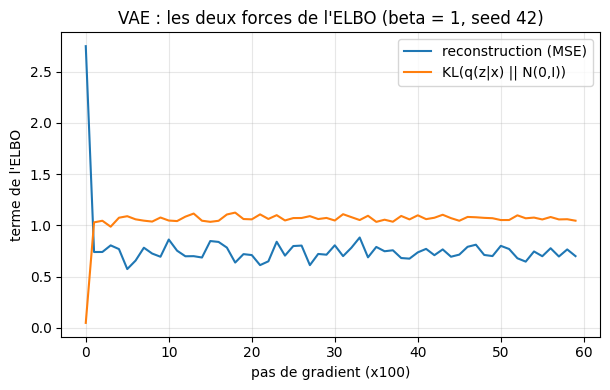

In [5]:
# --- Modele 1 : le VAE --- encoder mu/logvar, reparametrisation, decodeur, ELBO
def train_vae(seed, beta=1.0, verbose=False):
    rng = np.random.default_rng(seed)
    enc = MLP([2, H, H, 4], rng)          # sortie : (mu_1, mu_2, logvar_1, logvar_2)
    dec = MLP([2, H, H, 2], rng)
    opt = Adam(enc.params() + dec.params(), 1e-3)
    hist_recon, hist_kl = [], []
    for step in range(STEPS):
        xb = X[rng.integers(0, N_TRAIN, BATCH)]
        h = enc.forward(xb)
        mu, lv = h[:, :2], h[:, 2:]
        eps = rng.normal(0, 1, (BATCH, 2))          # le bruit FIXE de la reparametrisation
        z = mu + np.exp(0.5 * lv) * eps
        xr = dec.forward(z)
        recon = ((xr - xb) ** 2).sum(1).mean()      # -log p(x|z) gaussien (a une cte pres)
        kl = 0.5 * (np.exp(lv) + mu ** 2 - 1 - lv).sum(1).mean()   # KL(q(z|x) || N(0,I))
        dz, gd = dec.backward(2 * (xr - xb) / BATCH)
        dmu = dz + beta * mu / BATCH
        dlv = dz * np.exp(0.5 * lv) * eps * 0.5 + beta * 0.5 * (np.exp(lv) - 1) / BATCH
        _, ge = enc.backward(np.concatenate([dmu, dlv], 1))
        opt.step(ge + gd)
        if step % 100 == 0:
            hist_recon.append(recon); hist_kl.append(kl)
    return enc, dec, hist_recon, hist_kl

def vae_echantillon(dec, n, rng):
    z = rng.normal(0, 1, (n, 2))                    # prior N(0,I)
    return dec.forward(z)

t0 = time.time()
ENC, DEC, HIST_RECON, HIST_KL = train_vae(SEED)
T_VAE = time.time() - t0
print(f"VAE : {ENC.n_params() + DEC.n_params()} parametres, {STEPS} pas, {T_VAE:.1f} s")
print(f"ELBO final : reconstruction {HIST_RECON[-1]:.3f} + KL {HIST_KL[-1]:.2f}")

fig, ax = plt.subplots(figsize=(6.2, 4))
ax.plot(HIST_RECON, label="reconstruction (MSE)")
ax.plot(HIST_KL, label="KL(q(z|x) || N(0,I))")
ax.set_xlabel("pas de gradient (x100)"); ax.set_ylabel("terme de l'ELBO")
ax.set_title(f"VAE : les deux forces de l'ELBO (beta = 1, seed {SEED})")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

VAE : couverture 8/8 | equilibre 0.999 | dispersion 6.10


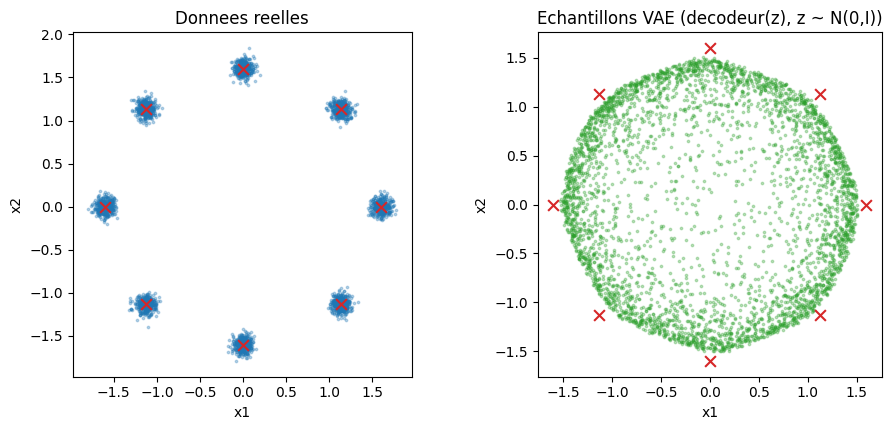

In [6]:
# Echantillons du VAE : le prior traverse le decodeur en UN passage
S_VAE = vae_echantillon(DEC, N_ECH, np.random.default_rng(SEED + 100))
print(f"VAE : couverture {couverture(S_VAE)}/8 | equilibre {equilibre(S_VAE):.3f} | dispersion {dispersion_relative(S_VAE):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.4))
axes[0].scatter(X[:3000, 0], X[:3000, 1], s=3, alpha=0.3, color="tab:blue")
axes[0].set_title("Donnees reelles")
axes[1].scatter(S_VAE[:, 0], S_VAE[:, 1], s=3, alpha=0.3, color="tab:green")
axes[1].set_title("Echantillons VAE (decodeur(z), z ~ N(0,I))")
for ax in axes:
    ax.scatter(CENTERS[:, 0], CENTERS[:, 1], s=60, marker="x", color="tab:red")
    ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

**Lecture — le VAE couvre, mais il moyenne.** Couverture 8/8 et équilibre ~1,0 : chaque mode reçoit sa part de masse — la régularisation KL force le latent à rester proche du prior, donc *aucun* mode n'est abandonné. Mais la **dispersion ~6** dit l'échec : les échantillons s'écartent des centres d'environ six fois la largeur des vraies données. Le décodeur, poussé par la reconstruction *et* par la KL, apprend une **moyenne locale** — entre deux modes voisins, il prédit le milieu du chemin ; l'espace latent mélange les régions et la sortie « bave » le long de l'anneau. C'est l'échec canonique du VAE en espace continu : le **moyennage** (l'équivalent 2D du flou des VAE d'images). La reconstruction reste excellente (le terme MSE de la courbe), mais la *génération* depuis le prior est floue — et le curseur $\beta$ gouverne l'arbitrage (exercice 1).

GAN : 4866 (G) + 4417 (D) parametres, 6000 pas, 32.6 s


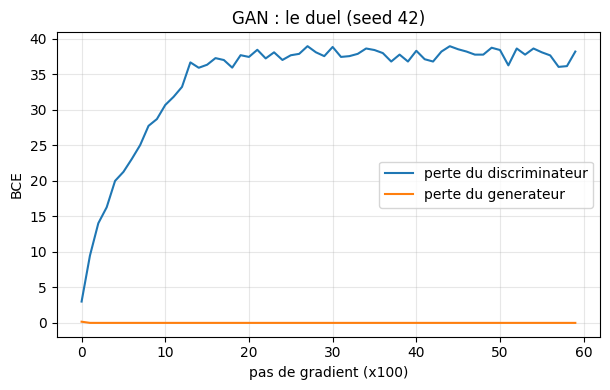

In [7]:
# --- Modele 2 : le GAN --- generateur vs discriminateur, BCE, mises a jour alternees
Z_DIM = 8   # dimension du bruit d'entree du generateur

def train_gan(seed, n_disc=1, verbose=False):
    rng = np.random.default_rng(seed)
    G = MLP([Z_DIM, H, H, 2], rng)
    D = MLP([2, H, H, 1], rng)
    optG = Adam(G.params(), 2e-4); optD = Adam(D.params(), 2e-4)
    hist_D, hist_G = [], []
    step = 0
    while step < STEPS:
        for _ in range(n_disc):                     # n_disc pas du discriminateur par pas du generateur
            if step >= STEPS: break
            xb = X[rng.integers(0, N_TRAIN, BATCH)]
            zf = rng.normal(0, 1, (BATCH, Z_DIM))
            xf = G.forward(zf)
            dr = 1 / (1 + np.exp(-D.forward(xb)))   # sigmoid
            df = 1 / (1 + np.exp(-D.forward(xf)))
            perte_D = -(np.log(dr + 1e-12).mean() + np.log(1 - df + 1e-12).mean())
            _, gD1 = D.backward((dr - 1) / BATCH)   # d/dlogit de -log sigmoid
            dxf, gD2 = D.backward(df / BATCH)       # d/dlogit de -log(1 - sigmoid)
            optD.step(gD1 + gD2)
            step += 1
        zf = rng.normal(0, 1, (BATCH, Z_DIM))
        xf = G.forward(zf)
        df = 1 / (1 + np.exp(-D.forward(xf)))
        perte_G = -np.log(df + 1e-12).mean()
        dxf, _ = D.backward((df - 1) / BATCH)       # maximiser log D(G(z))
        _, gG = G.backward(dxf)
        optG.step(gG)
        if step % 100 == 0:
            hist_D.append(perte_D); hist_G.append(perte_G)
    return G, hist_D, hist_G

def gan_echantillon(G, n, rng):
    return G.forward(rng.normal(0, 1, (n, Z_DIM)))

t0 = time.time()
G_NET, HIST_D, HIST_G = train_gan(SEED)
T_GAN = time.time() - t0
print(f"GAN : {G_NET.n_params()} (G) + {MLP([2, H, H, 1], np.random.default_rng(0)).n_params()} (D) parametres, {STEPS} pas, {T_GAN:.1f} s")

fig, ax = plt.subplots(figsize=(6.2, 4))
ax.plot(HIST_D, label="perte du discriminateur")
ax.plot(HIST_G, label="perte du generateur")
ax.set_xlabel("pas de gradient (x100)"); ax.set_ylabel("BCE")
ax.set_title(f"GAN : le duel (seed {SEED})")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

GAN : couverture 2/8 | equilibre 0.114 | dispersion 15.66
Occupation par mode :  6.2% 93.7%  0.0%  0.0%  0.0%  0.0%  0.0%  0.0%


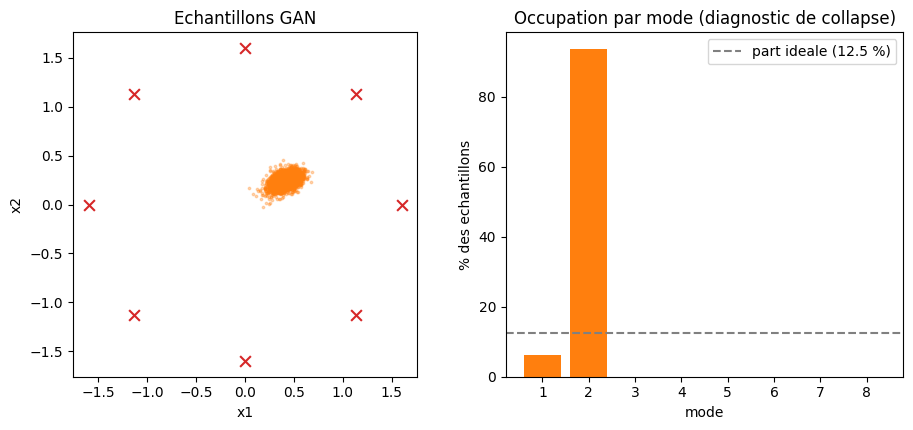

In [8]:
# Echantillons du GAN : occupation par mode + diagnostic de collapse
S_GAN = gan_echantillon(G_NET, N_ECH, np.random.default_rng(SEED + 100))
parts_gan = occupation(S_GAN)
print(f"GAN : couverture {couverture(S_GAN)}/8 | equilibre {equilibre(S_GAN):.3f} | dispersion {dispersion_relative(S_GAN):.2f}")
print("Occupation par mode :", " ".join(f"{p*100:4.1f}%" for p in parts_gan))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.4))
axes[0].scatter(S_GAN[:, 0], S_GAN[:, 1], s=3, alpha=0.3, color="tab:orange")
axes[0].scatter(CENTERS[:, 0], CENTERS[:, 1], s=60, marker="x", color="tab:red")
axes[0].set_title("Echantillons GAN")
axes[0].set_xlabel("x1"); axes[0].set_ylabel("x2"); axes[0].set_aspect("equal")
axes[1].bar(np.arange(N_MODES) + 1, parts_gan * 100, color="tab:orange")
axes[1].axhline(100 / N_MODES, ls="--", color="gray", label="part ideale (12.5 %)")
axes[1].set_title("Occupation par mode (diagnostic de collapse)")
axes[1].set_xlabel("mode"); axes[1].set_ylabel("% des echantillons"); axes[1].legend()
plt.tight_layout(); plt.show()

**Lecture — le GAN est net mais s'effondre.** Couverture 2/8 (ici) : le générateur concentre sa production sur un ou deux modes et **abandonne les autres** — le *mode collapse*, échec canonique du GAN. L'histogramme d'occupation le montre sans ambiguïté : deux barres démesurées, six quasi nulles. La dispersion élevée (~15) ajoute le placement : même les modes servis sont décalés des centres. Le pourquoi est dans l'objectif : le générateur maximise $\log D(G(z))$ — rien ne récompense la *diversité* ; si deux points du bruit produisent le même mode qui trompe $D$, le duel est satisfait. Les courbes de perte racontent l'autre symptôme : le duel oscille sans converger (là où VAE et diffusion descendent proprement leur coût). C'est un **équilibre de jeu**, pas un minimum — et l'exercice 2 sonde le levier classique ($n_{disc}$, le nombre de pas du discriminateur).

abar_T = 0.0096 (le point de depart de l'echantillonnage est quasi N(0,I))


Diffusion : 4930 parametres, 6000 pas, 9.2 s, MSE finale 0.503


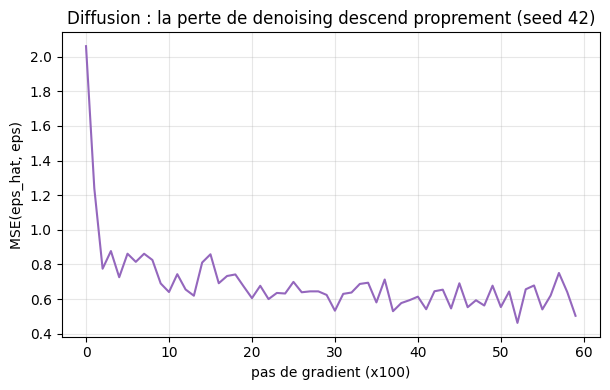

In [9]:
# --- Modele 3 : la diffusion (DDPM) --- processus direct, schedule, prediction du bruit
# Processus direct (ferme, aucun parametre a apprendre) : q(x_t | x_0) = N(sqrt(abar_t) x_0, (1-abar_t) I)
# Le reseau n'apprend PAS la distribution : il apprend eps_hat(x_t, t) ~ le bruit ajoute.
# Schedule lineaire choisi pour que abar_T ~ 0.01 : le dernier pas est (presque) du bruit pur N(0,I).
print(f"abar_T = {ALPHAS_CUM[-1]:.4f} (le point de depart de l'echantillonnage est quasi N(0,I))")

def train_ddpm(seed, lr=3e-3):
    rng = np.random.default_rng(seed)
    net = MLP([2 + 7, H, H, 2], rng)               # entree : (x_t, t_feat) -> eps_hat
    opt = Adam(net.params(), lr)
    hist = []
    for step in range(STEPS):
        xb = X[rng.integers(0, N_TRAIN, BATCH)]
        tt = rng.integers(0, T, BATCH)              # t uniforme
        eps = rng.normal(0, 1, (BATCH, 2))
        xt = np.sqrt(ALPHAS_CUM[tt])[:, None] * xb + np.sqrt(1 - ALPHAS_CUM[tt])[:, None] * eps
        inp = np.concatenate([xt, t_feat(tt / T)], 1)
        eh = net.forward(inp)
        perte = ((eh - eps) ** 2).sum(1).mean()     # MSE sur le bruit
        _, g = net.backward(2 * (eh - eps) / BATCH)
        opt.step(g)
        if step % 100 == 0:
            hist.append(perte)
    return net, hist

t0 = time.time()
NET_DDPM, HIST_DDPM = train_ddpm(SEED)
T_DDPM = time.time() - t0
print(f"Diffusion : {NET_DDPM.n_params()} parametres, {STEPS} pas, {T_DDPM:.1f} s, MSE finale {HIST_DDPM[-1]:.3f}")

fig, ax = plt.subplots(figsize=(6.2, 4))
ax.plot(HIST_DDPM, color="tab:purple")
ax.set_xlabel("pas de gradient (x100)"); ax.set_ylabel("MSE(eps_hat, eps)")
ax.set_title(f"Diffusion : la perte de denoising descend proprement (seed {SEED})")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Diffusion : couverture 8/8 | equilibre 0.993 | dispersion 1.50
Coût d'echantillonnage : 1.15 s pour 4096 points (100 passes du reseau) — contre 1 passe pour le VAE ou le GAN


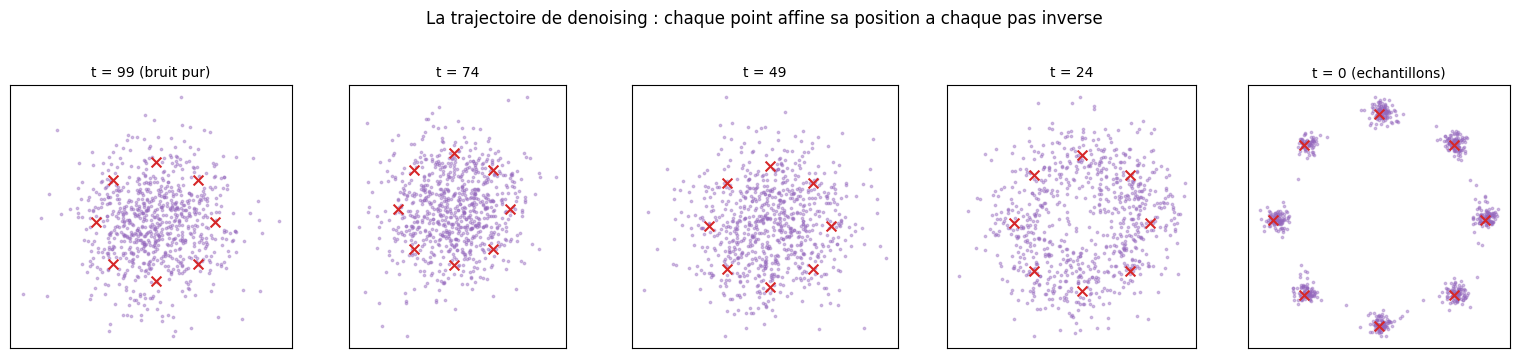

In [10]:
# Echantillonnage inverse : du bruit pur aux modes, PAS A PAS — et la trajectoire visible
def ddpm_echantillon(net, n, rng, pas=None, trajectoire=False):
    """Echantillonnage ancestral : pas = nombre de pas inverses (<= T)."""
    if pas is None:
        idx = np.arange(T - 1, -1, -1)
    else:
        idx = np.linspace(T - 1, 0, pas).astype(int)
    x = rng.normal(0, 1, (n, 2))                    # depart : N(0,I)
    snaps = []
    # etats photographies AVANT le pas marque -> snaps[0] = bruit pur, ..., snaps[4] = echantillons finaux
    marquage = {0, len(idx) // 4, len(idx) // 2, 3 * len(idx) // 4} if trajectoire else set()
    for i, t in enumerate(idx):
        if trajectoire and i in marquage:
            snaps.append(x.copy())
        tt = np.full(n, t)
        inp = np.concatenate([x, t_feat(tt / T)], 1)
        eh = net.forward(inp)
        a, b = ALPHAS_CUM[t], BETAS[t]
        x = (x - b / np.sqrt(1 - a) * eh) / np.sqrt(1 - b)   # moyenne de q(x_{t-1} | x_t, x_0_hat)
        if t > 0:
            x = x + np.sqrt(b) * rng.normal(0, 1, (n, 2))    # variance sigma_t^2 = beta_t
    if trajectoire:
        snaps.append(x.copy())
        return x, snaps
    return x

t0 = time.time()
S_DDPM, SNAPS = ddpm_echantillon(NET_DDPM, N_ECH, np.random.default_rng(SEED + 100), trajectoire=True)
T_SAMP_DDPM = time.time() - t0
print(f"Diffusion : couverture {couverture(S_DDPM)}/8 | equilibre {equilibre(S_DDPM):.3f} | dispersion {dispersion_relative(S_DDPM):.2f}")
print(f"Coût d'echantillonnage : {T_SAMP_DDPM:.2f} s pour {N_ECH} points ({T} passes du reseau) — contre 1 passe pour le VAE ou le GAN")

fig, axes = plt.subplots(1, 5, figsize=(15.5, 3.4))
titres = ["t = 99 (bruit pur)", "t = 74", "t = 49", "t = 24", "t = 0 (echantillons)"]
for k, (ax, snap, titre) in enumerate(zip(axes, SNAPS, titres)):
    ax.scatter(snap[:800, 0], snap[:800, 1], s=3, alpha=0.4, color="tab:purple")
    ax.scatter(CENTERS[:, 0], CENTERS[:, 1], s=50, marker="x", color="tab:red")
    ax.set_title(titre, fontsize=10); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("La trajectoire de denoising : chaque point affine sa position a chaque pas inverse", y=1.04)
plt.tight_layout(); plt.show()

**Lecture — la diffusion raffine, et le paie en passes.** Couverture 8/8, équilibre ~1,0, et surtout **dispersion ~1,5** : quatre fois plus nette que le VAE, dix fois mieux placée que le GAN — à budget *identique* (6 000 pas, même largeur). La trajectoire raconte le mécanisme : les cinq instantanés montrent le nuage de bruit pur se contracter progressivement vers les huit modes — chaque pas inverse applique une petite correction $\epsilon_\theta(x_t, t)$, et la structure émerge **itérativement** au lieu d'être produite en un seul passage. Le prix est visible dans le chronomètre : échantillonner coûte $T = 100$ passes du réseau (1 seconde ici), contre une seule pour VAE et GAN — c'est LE compromis structurel de la famille, celui que les notebooks GenAI/Image paient avec leurs dizaines de pas de sampler à chaque image.

In [11]:
# Le protocole multi-graines : 4 graines x 3 familles, memes metriques — aucun echantillon choisi
def evalue(echantillons):
    return couverture(echantillons), equilibre(echantillons), dispersion_relative(echantillons)

resultats = {}
couts = {}
for seed in SEEDS:
    rng_eval = np.random.default_rng(seed + 100)
    t0 = time.time(); enc_s, dec_s, _, _ = train_vae(seed); t_v = time.time() - t0
    t0 = time.time(); g_s, _, _ = train_gan(seed); t_g = time.time() - t0
    t0 = time.time(); net_s, _ = train_ddpm(seed); t_d = time.time() - t0
    t0 = time.time(); s_d = ddpm_echantillon(net_s, N_ECH, np.random.default_rng(seed + 100)); t_s = time.time() - t0
    resultats[seed] = {
        "VAE":  evalue(vae_echantillon(dec_s, N_ECH, rng_eval)),
        "GAN":  evalue(gan_echantillon(g_s, N_ECH, rng_eval)),
        "DDPM": evalue(s_d),
        "GMM":  evalue(gmm_echantillon(GMM_MU, GMM_VAR, GMM_PI, N_ECH, rng_eval)),
    }
    couts[seed] = {"VAE": t_v, "GAN": t_g, "DDPM": t_d + t_s}
    cv, eq, dp = resultats[seed]["VAE"]; print(f"seed {seed:>2} : VAE {cv}/8 eq {eq:.2f} disp {dp:4.1f} ({t_v:4.0f}s)", end="  | ")
    cv, eq, dp = resultats[seed]["GAN"]; print(f"GAN {cv}/8 eq {eq:.2f} disp {dp:4.1f} ({t_g:4.0f}s)", end="  | ")
    cv, eq, dp = resultats[seed]["DDPM"]; print(f"DDPM {cv}/8 eq {eq:.2f} disp {dp:4.1f} ({t_d + t_s:4.0f}s)")

print()
print(f"{'famille':<8} {'couverture (moy +/- et)':<22} {'equilibre':<18} {'dispersion':<20} {'cout moy (s)'}")
for fam in ["GMM", "VAE", "GAN", "DDPM"]:
    covs = np.array([resultats[s][fam][0] for s in SEEDS], dtype=float)
    eqs  = np.array([resultats[s][fam][1] for s in SEEDS])
    dps  = np.array([resultats[s][fam][2] for s in SEEDS])
    cout = np.mean([couts[s][fam] for s in SEEDS]) if fam != "GMM" else T_FIT_GMM
    print(f"{fam:<8} {covs.mean():5.1f} +/- {covs.std():3.1f}        {eqs.mean():6.3f} +/- {eqs.std():.3f}  {dps.mean():6.2f} +/- {dps.std():4.2f}   {cout:6.1f}")

seed  0 : VAE 8/8 eq 1.00 disp  5.9 (  13s)  | GAN 2/8 eq 0.26 disp 16.6 (  35s)  | DDPM 8/8 eq 1.00 disp  1.4 (   8s)


seed  1 : VAE 8/8 eq 1.00 disp  6.0 (  15s)  | GAN 1/8 eq 0.00 disp 14.8 (  32s)  | DDPM 8/8 eq 0.99 disp  1.5 (  12s)


seed  7 : VAE 8/8 eq 1.00 disp  6.2 (  17s)  | GAN 1/8 eq 0.01 disp 15.0 (  31s)  | DDPM 8/8 eq 0.98 disp  1.6 (   9s)


seed 42 : VAE 8/8 eq 1.00 disp  6.1 (  16s)  | GAN 2/8 eq 0.12 disp 15.7 (  33s)  | DDPM 8/8 eq 0.99 disp  1.5 (  10s)

famille  couverture (moy +/- et) equilibre          dispersion           cout moy (s)
GMM        8.0 +/- 0.0         0.999 +/- 0.000    0.99 +/- 0.01      2.2
VAE        8.0 +/- 0.0         0.999 +/- 0.000    6.04 +/- 0.12     15.4
GAN        1.5 +/- 0.5         0.099 +/- 0.105   15.54 +/- 0.70     32.8
DDPM       8.0 +/- 0.0         0.992 +/- 0.005    1.51 +/- 0.06     10.0


**Lecture — le verdict multi-graines.** Quatre graines, mêmes métriques, aucune sélection d'échantillon. La colonne couverture raconte les trois familles en un coup d'œil : VAE et diffusion sont à 8/8 sur **toutes** les graines (écart-type nul), le GAN est à 1,5 ± 0,5 — l'instabilité entre graines est la signature du duel, chaque entraînement choisit ses modes au hasard. La dispersion sépare ensuite les deux couvrantes : ~6 pour le VAE (le moyennage, lui aussi présent sur toutes les graines), ~1,5 pour la diffusion — quatre fois plus nette, à budget identique. Et la baseline domine encore tout le monde : GMM à 0,99 de dispersion en deux secondes, sans un seul gradient — quand le biais inductif colle au problème, les 6 000 pas des réseaux sont superflus. Reste le compromis invisible du tableau : chaque échantillon de diffusion paie 100 passes de réseau (contre une pour VAE et GAN) — le prix du raffinement itératif, que l'exercice 3 mesure à la casse.

## Exercices

Trois sondes pour prolonger l'étude — chaque exercice réutilise les fonctions paramétrées du notebook (`train_vae(seed, beta=…)`, `train_gan(seed, n_disc=…)`, `ddpm_echantillon(net, n, rng, pas=…)`), avec les mêmes métriques (`couverture`, `equilibre`, `dispersion_relative`).

**Exercice 1 — le curseur $\beta$ du VAE.** Le moyennage vient de l'arbitrage reconstruction/KL. Réentraînez le VAE pour $\beta \in \{0{,}05,\ 1{,}0,\ 5{,}0\}$ et tracez couverture et dispersion en fonction de $\beta$. *Que doit-on voir ?* Un $\beta$ faible libère la reconstruction (dispersion qui baisse) mais laisse le prior mal rempli (des modes peuvent disparaître — couverture qui chute) ; un $\beta$ fort pousse au moyennage. Le VAE ne « gagne » jamais sur les deux tableaux — c'est une borne, pas la vraisemblance.

**Exercice 2 — le levier $n_{disc}$ du GAN.** Le duel s'équilibre différemment selon le rythme des mises à jour du discriminateur. Réentraînez pour $n_{disc} \in \{1, 3\}$ sur les 4 graines et comparez la *stabilité* (écart-type de la couverture entre graines) et la couverture moyenne. *Piste* : un discriminateur plus entraîné donne un gradient plus informatif au générateur — ou écrase le duel si $D$ devient parfait (le gradient s'évanouit).

**Exercice 3 — échantillonner la diffusion en moins de pas.** La trajectoire inverse utilise ici $T = 100$ pas. Rééchantillonnez le réseau déjà entraîné (`NET_DDPM`) avec `pas` $\in \{100, 50, 25, 10\}$ et mesurez couverture/dispersion + temps. *Que doit-on voir ?* La qualité se dégrade doucement puis brutalement — le pas inverse devient trop gros pour la correction apprise. C'est exactement le compromis que les samplers accélérés des notebooks GenAI/Image (moins de pas, meilleurs schedules) négocient.

In [12]:
# Exercice 1 : beta du VAE vs (couverture, dispersion)
resultats_beta = None  # TODO etudiant : pour beta dans [0.05, 1.0, 5.0], reentrainer train_vae(SEED, beta=beta)
# puis evaluer vae_echantillon(dec, N_ECH, ...) -> couverture() et dispersion_relative() ; tracer l'arbitrage.
print("Exercice a completer : l'arbitrage beta — couverture perdue d'un cote, dispersion gagnee de l'autre")

Exercice a completer : l'arbitrage beta — couverture perdue d'un cote, dispersion gagnee de l'autre


In [13]:
# Exercice 2 : n_disc du GAN vs stabilite multi-graines
resultats_ndisc = None  # TODO etudiant : pour n_disc dans [1, 3], entrainer train_gan(seed, n_disc=...) sur SEEDS
# puis comparer moyenne et ecart-type de la couverture ; le duel s'equilibre-t-il mieux ?
print("Exercice a completer : n_disc — le duel s'equilibre-t-il mieux ?")

Exercice a completer : n_disc — le duel s'equilibre-t-il mieux ?


In [14]:
# Exercice 3 : nombre de pas d'echantillonnage de la diffusion
resultats_pas = None  # TODO etudiant : pour pas dans [100, 50, 25, 10], ddpm_echantillon(NET_DDPM, N_ECH, rng, pas=pas)
# mesurer couverture/dispersion + temps ; ou la qualite cesse-t-elle d'etre tenable ?
print("Exercice a completer : combien de pas peut-on retirer avant que la trajectoire casse ?")

Exercice a completer : combien de pas peut-on retirer avant que la trajectoire casse ?


## Conclusion et transition

Trois familles, un même budget, une même cible — **trois échecs différents**, et c'était la leçon. Le **VAE** couvre tout et moyenne partout (dispersion ~6) : son ELBO est une *borne*, et la KL qui garantit la couverture fabrique le flou. Le **GAN** place mal et s'effondre (1 à 2 modes sur 8, instability entre graines) : son objectif est un duel, et rien n'y récompense la couverture. La **diffusion** s'en sort le mieux des trois (8/8, dispersion ~1,5, stable sur toutes les graines) parce qu'elle remplace la génération en un passage par un **raffinement itératif** — et c'est aussi son coût : chaque échantillon paie 100 passes de réseau. La baseline **GMM**, elle, domine tout le monde tant que le biais inductif colle au problème — le rappel salutaire avant de conclure « le deep learning a gagné ».

Le pont vers le reste du dépôt se lit maintenant mécaniquement. Le **VAE temporel de [QC-Py-24](../../../QuantConnect/Python/QC-Py-24-Autoencoders-Anomaly.ipynb)** est exactement le modèle de ce notebook (encodeur → espace latent → décodeur, ELBO) transféré aux séries de rendements : sa détection d'anomalie par erreur de reconstruction est le terme « reconstruction » de notre courbe — et son espace latent en basse dimension y joue le même rôle de régularisateur que notre KL. Les **notebooks GenAI/Image** consomment le troisième mécanisme : leur « sampler à N pas », leur « noise schedule », leur CFG sont les hyperparamètres de *notre* DDPM — passés de $x \in \mathbb{R}^2$ à l'espace latent d'un UNet de centaines de millions de paramètres. Le mécanisme (prédire le bruit, débruiter pas à pas) est identique ; l'échelle et le conditionnement changent tout — ce notebook n'a prétendu démontrer ni FLUX ni Stable Diffusion, seulement le moteur qu'ils partagent.

## References

- **Kingma, D. P. & Welling, M. (2013).** *Auto-Encoding Variational Bayes.* arXiv:1312.6114. — L'article fondateur du VAE : la borne ELBO et l'astuce de reparamétrisation qui la rend différentiable.
- **Goodfellow, I. et al. (2014).** *Generative Adversarial Nets.* NeurIPS. — Le duel minimax générateur/discriminateur ; la section 4 discute déjà le mode collapse que nous avons mesuré.
- **Ho, J., Jain, A. & Abbeel, P. (2020).** *Denoising Diffusion Probabilistic Models.* NeurIPS. — Le DDPM moderne : prédiction du bruit, schedule linéaire, échantillonnage ancestral — exactement notre implémentation, à l'échelle des images près.
- **Song, Y. & Ermon, S. (2019).** *Generative Modeling by Estimating Gradients of the Data Distribution.* NeurIPS. — La vue duale (scores) qui a nourri la famille diffusion.